In [1]:
import numpy as np 

In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv("spam.csv", encoding="ISO-8859-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]) 

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
from sklearn.preprocessing import LabelEncoder 

lb = LabelEncoder() 

In [6]:
df["v1"] = lb.fit_transform(df["v1"]) 
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df["v1"].value_counts()

v1
0    4825
1     747
Name: count, dtype: int64

In [8]:
df = df.rename(columns = {'v1': 'target', 'v2': 'text'})

df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df["target"].isnull().sum()

0

In [10]:
df["text"].isnull().sum() 

0

In [11]:
df["num_characters"] = df["text"].apply(len) 

In [12]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [13]:
import re

def tokenize(sentence):
    tokens = re.findall(r'\b\w+\b', sentence)
    return tokens

In [14]:
df["num_words"] = df["text"].apply(lambda x: len(tokenize(x)))

df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,33
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,14


In [15]:
import spacy

In [16]:
# Load the English model
nlp = spacy.load("en_core_web_sm")

def split_into_sentences(text):
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents]


In [17]:
split_into_sentences(df["text"][0])

['Go until jurong point, crazy..',
 'Available only in bugis n great world la e buffet...',
 'Cine there got amore wat...']

In [18]:
df["num_sentences"] = df['text'].apply(lambda x: len(split_into_sentences(x)))

df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,33,2
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,14,1


In [19]:
df[["num_characters", "num_words", "num_sentences"]].describe() 

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,16.171213,2.125987
std,59.690841,11.776037,1.516354
min,2.000000,0.000000,1.000000
25%,36.000000,8.000000,1.000000
50%,61.000000,12.000000,2.000000
75%,121.000000,24.000000,3.000000
max,910.000000,190.000000,27.000000


In [20]:
#ham
df[df["target"] == 0].describe()

,target,num_characters,num_words,num_sentences
count,4825.0,4825.000000,4825.000000,4825.000000
mean,0.0,71.023627,14.677098,1.973679
std,0.0,58.016023,11.738398,1.458069
min,0.0,2.000000,0.000000,1.000000
25%,0.0,33.000000,7.000000,1.000000
50%,0.0,52.000000,11.000000,2.000000
75%,0.0,92.000000,19.000000,2.000000
max,0.0,910.000000,190.000000,27.000000


In [21]:
#spam 
df[df["target"] == 1].describe() 

,target,num_characters,num_words,num_sentences
count,747.0,747.000000,747.000000,747.000000
mean,1.0,138.866131,25.821954,3.109772
std,0.0,29.183082,6.073204,1.517988
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.500000,24.000000,2.000000
50%,1.0,149.000000,27.000000,3.000000
75%,1.0,157.000000,30.000000,4.000000
max,1.0,224.000000,40.000000,9.000000


In [22]:
df[df["target"] == 0]["num_characters"]

0       111
1        29
3        49
4        61
6        77
       ... 
5565     12
5568     37
5569     57
5570    125
5571     26
Name: num_characters, Length: 4825, dtype: int64

<Axes: xlabel='num_characters', ylabel='Count'>

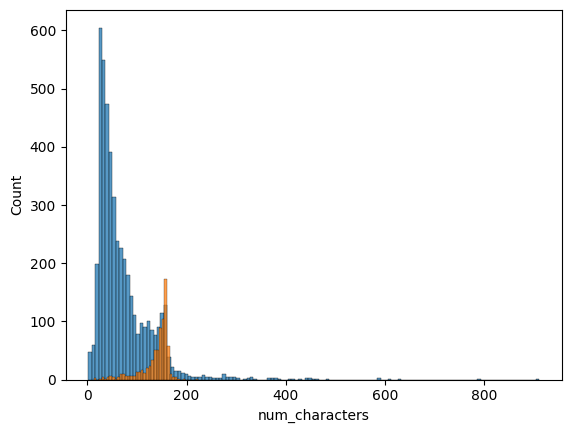

In [23]:
import seaborn as sns

sns.histplot(df[df["target"] == 0]["num_characters"])
sns.histplot(df[df["target"] == 1]["num_characters"]) 

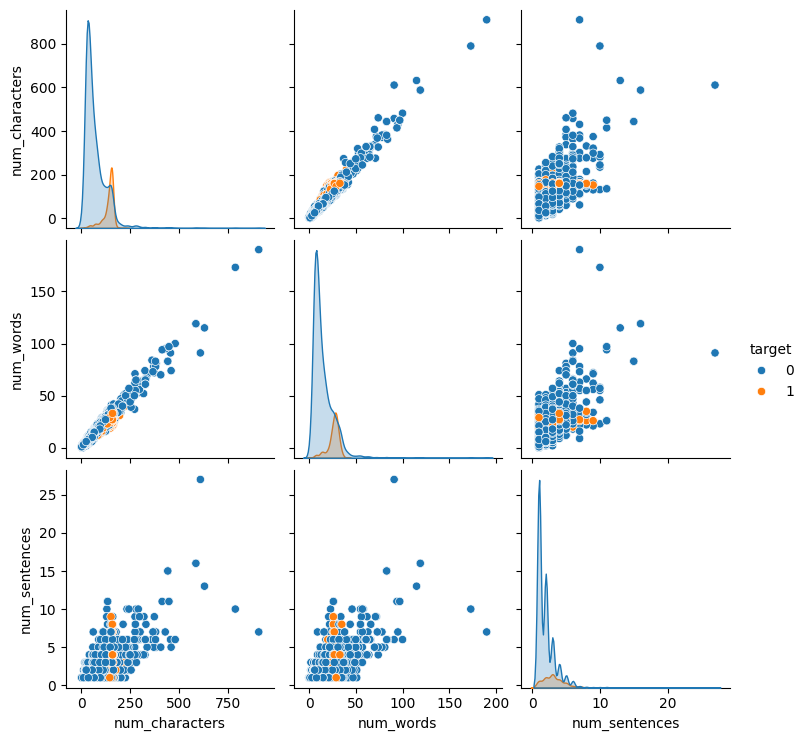

In [24]:
sns.pairplot(df, hue="target") 

<Axes: >

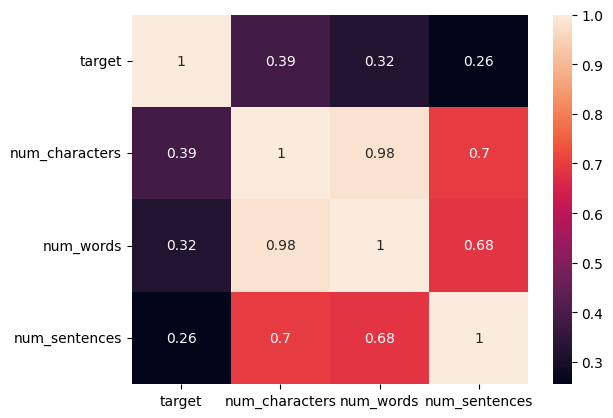

In [25]:
sns.heatmap(df[["target", "num_characters", "num_words", "num_sentences"]].corr(), annot = True) 

In [36]:
stopwords = nlp.Defaults.stop_words

stopwords

{"'d",
 "'ll",
 "'m",
 "'re",
 "'s",
 "'ve",
 'a',
 'about',
 'above',
 'across',
 'after',
 'afterwards',
 'again',
 'against',
 'all',
 'almost',
 'alone',
 'along',
 'already',
 'also',
 'although',
 'always',
 'am',
 'among',
 'amongst',
 'amount',
 'an',
 'and',
 'another',
 'any',
 'anyhow',
 'anyone',
 'anything',
 'anyway',
 'anywhere',
 'are',
 'around',
 'as',
 'at',
 'back',
 'be',
 'became',
 'because',
 'become',
 'becomes',
 'becoming',
 'been',
 'before',
 'beforehand',
 'behind',
 'being',
 'below',
 'beside',
 'besides',
 'between',
 'beyond',
 'both',
 'bottom',
 'but',
 'by',
 'ca',
 'call',
 'can',
 'cannot',
 'could',
 'did',
 'do',
 'does',
 'doing',
 'done',
 'down',
 'due',
 'during',
 'each',
 'eight',
 'either',
 'eleven',
 'else',
 'elsewhere',
 'empty',
 'enough',
 'even',
 'ever',
 'every',
 'everyone',
 'everything',
 'everywhere',
 'except',
 'few',
 'fifteen',
 'fifty',
 'first',
 'five',
 'for',
 'former',
 'formerly',
 'forty',
 'four',
 'from',
 'fron

In [71]:
def text_transformation(text):
    text = text.lower()
    doc = nlp(text) 
    tokens = [token.text for token in doc if not token.is_stop]
    tokens = [token for token in tokens if token.isalnum()]
    tokens = nlp(" ".join(tokens))
    lemmatized_tokens = [token.lemma_ for token in tokens]

    return " ".join(lemmatized_tokens)

In [72]:
text_transformation("Hi! how are you Dhanush?") 

'hi dhanush'

In [73]:
print(text_transformation(df["text"][0]))  

jurong point crazy available bugis n great world la e buffet cine get amore wat


In [75]:
df["transformed_text"] = df["text"].apply(text_transformation) 

df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,33,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun early hor u c
4,0,"Nah I don't think he goes to usf, he lives aro...",61,14,1,nah think go usf life


In [128]:
from sklearn.feature_extraction.text import CountVectorizer 

cv = CountVectorizer() 

In [129]:
df["transformed_text"]

0       jurong point crazy available bugis n great wor...
1                                 ok lar joking wif u oni
2       free entry 2 wkly comp win fa cup final tkts 2...
3                                     u dun early hor u c
4                                   nah think go usf life
                              ...                        
5567    2nd time try 2 contact u win pound prize 2 cla...
5568                             ì b go esplanade fr home
5569                                 pity mood suggestion
5570    guy bitching act like interested buying week g...
5571                                            rofl true
Name: transformed_text, Length: 5572, dtype: object

In [130]:
x = cv.fit_transform(df["transformed_text"]).toarray()

In [131]:
x.shape

(5572, 7029)

In [132]:
y = np.array(df["target"].tolist())

In [133]:
y.shape

(5572,)

In [134]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state=42)  

In [135]:
from sklearn.naive_bayes import MultinomialNB 

nb = MultinomialNB() 

In [136]:
nb.fit(X_train, y_train) 

MultinomialNB()

In [137]:
y_pred = nb.predict(X_test) 

In [138]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred)) 

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1202
           1       0.91      0.92      0.91       191

    accuracy                           0.98      1393
   macro avg       0.95      0.95      0.95      1393
weighted avg       0.98      0.98      0.98      1393



In [139]:
import pickle as pk 

with open("spam_ham_model.pkl", "wb") as f:
    pk.dump(nb, f) 

In [143]:
user_input = "Fuck you bitch shit asshole"
user_input = text_transformation(user_input)
user_vec = cv.transform([user_input]) # Use transform, NOT fit_transform
prediction = nb.predict(user_vec)
print(prediction[0])

0


In [144]:
with open("cv_vectorizer.pkl", "wb") as c:
    pk.dump(cv, c)